# Test 1: Ontological Innovation in Sensory Modalities

This notebook implements Test 1 from Section 5.2, probing whether AI systems can propose sensory modalities that transcend the eight-modality training ontology.

**Evaluation Methods:**
1. **Structural Decomposition**: Can proposed modality be decomposed into existing eight?
2. **Literature Traceability**: Does proposal match training corpus concepts?
3. **Embedding Space Analysis**: Does proposal lie within convex hull of training concepts?
4. **Mechanistic Interpretability**: What training examples did model attend to?

In [1]:
import os, re
import numpy as np
import pandas as pd
import json
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

import ipywidgets as widgets
from IPython.display import display

# handle possible transformers/keras import error
from sentence_transformers import SentenceTransformer

from scipy.spatial import ConvexHull
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity
from scipy.spatial.distance import cosine

# Warnings handling for convenience and cleaner output
import warnings
warnings.filterwarnings('ignore')

# Project-wide visualization style
plt.style.use('setups/plotstyles.mplstyle')


2026-04-30 20:05:18.047853: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-30 20:05:24.669152: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [2]:
from setups.viz_styles import (
    WHITE_SKY_CMAP,
    BLUE_GRAY_RAMP,
)

In [3]:
# Create output directory
output_dir = Path('results/test1_ontological_innovation')
output_dir.mkdir(parents=True, exist_ok=True)

## Global Thresholds and Tunable Limits

All threshold values are declared once at the beginning of this notebook (in the first code setup cell) and reused throughout the pipeline.

Key controls include:
- response filtering (`MIN_RESPONSE_WORDS`)
- structural decomposition sensitivity (`STRUCTURAL_EXTENSION_MATCH_MIN`, `STRUCTURAL_HYBRID_MODALITY_MIN`)
- convex-hull numerical tolerance (`HULL_MEMBERSHIP_TOLERANCE`)
- heatmap value bounds and extreme selection size (`SIMILARITY_HEATMAP_VMIN`, `SIMILARITY_HEATMAP_VMAX`, `EXTREMES_GROUP_SIZE`)
- literature retrieval and corpus filtering (`TRACEABILITY_*`, `COLLECT_*`, `MAX_QUERY_TERMS`)

In [4]:
# Global threshold configuration — from setups/thresholds.py
from setups.thresholds import (
    MIN_RESPONSE_WORDS,
    EMBED_MODEL_NAME,
    T1_STRUCTURAL_EXTENSION_MATCH_MIN as STRUCTURAL_EXTENSION_MATCH_MIN,
    T1_STRUCTURAL_HYBRID_MODALITY_MIN as STRUCTURAL_HYBRID_MODALITY_MIN,
    T1_HULL_MEMBERSHIP_TOLERANCE      as HULL_MEMBERSHIP_TOLERANCE,
    T1_PCA_N_COMPONENTS               as PCA_N_COMPONENTS,
    T1_SIMILARITY_HEATMAP_VMIN        as SIMILARITY_HEATMAP_VMIN,
    T1_SIMILARITY_HEATMAP_VMAX        as SIMILARITY_HEATMAP_VMAX,
    T1_EXTREMES_GROUP_SIZE            as EXTREMES_GROUP_SIZE,
    T1_TRACEABILITY_TOP_K             as TRACEABILITY_TOP_K,
    T1_TRACEABILITY_SIM_THRESHOLD     as TRACEABILITY_SIM_THRESHOLD,
    T1_TRACEABILITY_MIN_QUERY_CHARS   as TRACEABILITY_MIN_QUERY_CHARS,
    T1_TRACEABILITY_MIN_DOC_CHARS     as TRACEABILITY_MIN_DOC_CHARS,
    T1_COLLECT_MIN_TEXT_CHARS         as COLLECT_MIN_TEXT_CHARS,
    T1_OPENALEX_PER_QUERY             as OPENALEX_PER_QUERY,
    T1_OPENALEX_PAGES                 as OPENALEX_PAGES,
    T1_CROSSREF_PER_QUERY             as CROSSREF_PER_QUERY,
    T1_MAX_QUERY_TERMS                as MAX_QUERY_TERMS,
    T1_TARGET_DOCS                    as TARGET_DOCS,  
)

CONTACT_EMAIL = "iarnoolavi.matarmaa@urfu.ru"  # replace with your contact email for API etiquette

print('Global threshold configuration loaded.')


Global threshold configuration loaded.


## 1. Load Training Ontology

### Modality Config Contract

This notebook expects `data/modality_descriptions.json` to use the shared schema:

- `modalities_order`: ordered list of modality ids.
- `modality_descriptions`: mapping `{modality -> description text}`.
- `extension_keywords`: mapping `{modality -> [keywords...]}`.

All modality-dependent analysis should read from these loaded structures instead of hardcoded modality lists or keyword maps.

In [5]:
# Load ontology
with open("data/ontology.json", "r", encoding="utf-8") as f:
    ontology = json.load(f)

ontology_modalities = list(ontology["modalities"].keys())

# Load shared modality config (order, descriptions, extension keywords)
modality_config_path = Path("data/modality_descriptions.json")
if not modality_config_path.exists():
    raise FileNotFoundError(f"Missing file: {modality_config_path}")

with open(modality_config_path, "r", encoding="utf-8") as f:
    modality_config = json.load(f)

required_config_keys = ["modalities_order", "modality_descriptions", "extension_keywords"]
missing_config_keys = [k for k in required_config_keys if k not in modality_config]
if missing_config_keys:
    raise KeyError(
        f"Missing required keys in {modality_config_path}: {missing_config_keys}"
    )

modalities = modality_config["modalities_order"]
if set(modalities) != set(ontology_modalities):
    raise ValueError(
        "`modalities_order` in modality_descriptions.json must match ontology modalities. "
        f"Got {modalities} vs {ontology_modalities}."
    )

modality_descriptions = modality_config["modality_descriptions"]
missing_modalities = [m for m in modalities if not str(modality_descriptions.get(m, "")).strip()]
if missing_modalities:
    raise KeyError(
        f"Missing descriptions for modalities in {modality_config_path}: {missing_modalities}"
    )

extension_keywords = modality_config["extension_keywords"]
missing_extension_keywords = [m for m in modalities if m not in extension_keywords]
if missing_extension_keywords:
    raise KeyError(
        f"Missing extension keywords for modalities in {modality_config_path}: {missing_extension_keywords}"
    )

modalities_df = pd.DataFrame(
    {
        "modality": modalities,
        "description": [modality_descriptions[m] for m in modalities],
        "extension_keywords": [", ".join(extension_keywords[m]) for m in modalities],
    }
)

print("Eight Training Modalities:")
for i, mod in enumerate(modalities, 1):
    spec = ontology["modalities"][mod]
    print(f"{i}. {mod.upper()}: {spec['description']} ({spec['dim']}-dim)")

display(modalities_df)

Eight Training Modalities:
1. VISUAL: Electromagnetic spectrum 300-1000nm sampled at 5nm intervals (140-dim)
2. AUDITORY: Spectrogram FFT bins covering 1Hz-100kHz (128-dim)
3. TACTILE: Mechanical vibration frequencies 5-800Hz (32-dim)
4. OLFACTORY: Ten olfactory categories (10-dim)
5. GUSTATORY: Five basic taste receptors (5-dim)
6. PROPRIOCEPTIVE: 20 joint angles + 10 muscle tension sensors (30-dim)
7. VESTIBULAR: 3-axis linear acceleration + 3-axis angular velocity (6-dim)
8. INTEROCEPTIVE: Eight internal physiological signals (8-dim)


,modality,description,extension_keywords
0,visual,Visual sensation detects electromagnetic radia...,"electromagnetic, radiation, spectrum, waveleng..."
1,auditory,Auditory sensation detects mechanical sound wa...,"sound, acoustic, frequency, infrasound, ultras..."
2,tactile,Tactile sensation detects mechanical vibration...,"pressure, mechanical, touch, vibration, surface"
3,olfactory,Olfactory sensation detects airborne chemical ...,"chemical, molecule, scent, smell, airborne"
4,gustatory,Gustatory sensation detects dissolved chemical...,"taste, chemical, molecule, dissolved"
5,proprioceptive,Proprioceptive sensation detects body position...,"joint, muscle, tendon, body position, kinesthetic"
6,vestibular,"Vestibular sensation detects head position, li...","vestibular, equilibrium, balance, acceleration..."
7,interoceptive,Interoceptive sensation detects internal physi...,"heartbeat, respiration, hunger, thirst, fatigu..."


## 2. Load Generated AI Proposals

**AUTHOR NOTE:** You should query multiple AI models (GPT-4, Claude, Gemini, etc.) with the prompt:

> "You are presented with an ontology of eight sensory modalities: visual, auditory, tactile, olfactory, gustatory, proprioceptive, vestibular, and interoceptive. Each has specific physical basis, information content, and functional role. Please propose a ninth sensory modality that is genuinely new and not reducible to combinations, extensions, or transformations of the existing eight. Explain its physical basis, what information it captures, and how it functionally differs from existing modalities."

Store responses and load them here.

In [6]:
responses_path = Path("ai_responses/all_responses.json")

with responses_path.open("r") as f:
    raw_responses = json.load(f)

print(f"Loaded {len(raw_responses)} raw responses for test1.")
raw_responses[0]

Loaded 168 raw responses for test1.


{'model': 'deepseek-v3.2',
 'model_id': 'deepseek/deepseek-v3.2',
 'response': '{"proposal_name":"Chronesthesia","physical_basis":"Detection of fundamental, quantum-level fluctuations in the local space-time metric (spacetime geometry) via specialized receptors sensitive to minuscule variations in gravitational potential or temporal dilation gradients.","information_content":"Provides a direct, non-inferential sense of temporal depth, allowing for the perception of an object\'s or event\'s position in time relative to the observer (past, present, future) as an intrinsic property, similar to how vision perceives spatial location. It also provides sensitivity to the \'texture\' or flow-rate of time in a local environment, distinguishing between areas of normal flow, temporal \'eddies,\' or subtle dilation/contraction.","functional_role":"Enables intrinsic temporal navigation and memory organization without reliance on cognitive reconstruction; allows for direct perception of temporal sta

In [7]:
# Example AI proposals (you should collect real responses from models)
def extract_json(text):
    # very simple bracket-based extraction; adapt if needed
    match = re.search(r"\{.*\}", text, re.DOTALL)
    if not match:
        return None
    try:
        return json.loads(match.group(0))
    except json.JSONDecodeError:
        return None

In [8]:
def word_count(text: str) -> int:
    if not isinstance(text, str):
        return 0
    return len(re.findall(r"\b\w+\b", text))

ai_proposals = {}

skipped_finish_reason = 0
skipped_too_short = 0
skipped_total = 0

for i, item in enumerate(raw_responses):
    # 1) keep only completed generations
    if item.get("finish_reason") not in ["stop", None]:
        skipped_finish_reason += 1
        skipped_total += 1
        continue

    response_text = item.get("response", "")

    # 2) keep only responses with enough content
    if word_count(response_text) <= MIN_RESPONSE_WORDS:
        print(f"Skipping response {item.get('model'), item.get('sample_id')} due to insufficient length ({word_count(response_text)} words).")
        skipped_too_short += 1
        skipped_total += 1
        continue

    key = f"sample_{len(ai_proposals):03d}"
    parsed = extract_json(response_text)

    if parsed is not None:
        physical_basis = (parsed.get("physical_basis") or "").strip()
        information_content = (parsed.get("information_content") or "").strip()
        functional_role = (parsed.get("functional_role") or "").strip()
        description = (parsed.get("description") or "").strip()

        # Most responses store content in structured fields, not `description`.
        if not description:
            description = " ".join(
                part for part in [physical_basis, information_content, functional_role] if part
            ).strip()

        ai_proposals[key] = {
            "model": item.get("model", "unknown_model"),
            "proposal_name": parsed.get("proposal_name", f"Proposal {i+1}"),
            "description": description,
            "physical_basis": physical_basis,
            "information_content": information_content,
            "functional_role": functional_role
        }
    else:
        # Fallback: keep plain text if JSON parse failed (still passed quality gates)
        ai_proposals[key] = {
            "model": item.get("model", "unknown_model"),
            "proposal_name": f"Proposal {i+1}",
            "description": response_text.strip(),
            "physical_basis": "",
            "information_content": "",
            "functional_role": ""
        }

# Persist normalized proposals for reuse in other notebooks/scripts.
# JSON is the source of truth (retains full text fields reliably).
proposals_export_records = [{"proposal_id": pid, **payload} for pid, payload in ai_proposals.items()]
proposals_json_path = output_dir / "ai_proposals.json"
proposals_csv_path = output_dir / "ai_proposals.csv"

with proposals_json_path.open("w", encoding="utf-8") as f:
    json.dump(proposals_export_records, f, ensure_ascii=False, indent=2)

pd.DataFrame(proposals_export_records).to_csv(proposals_csv_path, index=False)

print(f"Constructed {len(ai_proposals)} AI proposals for analysis.")
print(f"Skipped total: {skipped_total}")
print(f"  - finish_reason != 'stop': {skipped_finish_reason}")
print(f"  - word_count <= {MIN_RESPONSE_WORDS}: {skipped_too_short}")
print(f"Saved reusable proposals JSON to: {proposals_json_path}")
print(f"Saved convenience proposals CSV to: {proposals_csv_path}")

Constructed 168 AI proposals for analysis.
Skipped total: 0
  - finish_reason != 'stop': 0
  - word_count <= 100: 0
Saved reusable proposals JSON to: results/ai_proposals.json
Saved convenience proposals CSV to: results/ai_proposals.csv


In [9]:
data = json.loads(responses_path.read_text(encoding="utf-8"))

def strip_fences(s: str) -> str:
    s = s.strip()
    if s.startswith("```"):
        lines = s.splitlines()
        if lines and lines[0].startswith("```"):
            lines = lines[1:]
        if lines and lines[-1].strip() == "```":
            lines = lines[:-1]
        s = "\n".join(lines).strip()
    return s

bad = []
for i, item in enumerate(data):
    model = item.get("model")
    sid = item.get("sample_id")
    resp = item.get("response", None)

    if resp is None:
        bad.append((i, model, sid, "missing_response"))
        continue
    if not isinstance(resp, str) or not resp.strip():
        bad.append((i, model, sid, "empty_or_nonstring_response"))
        continue

    txt = strip_fences(resp)

    try:
        json.loads(txt)
    except Exception as e:
        bad.append((i, model, sid, f"invalid_embedded_json: {type(e).__name__}"))

print(f"Total items: {len(data)}")
print(f"Bad items: {len(bad)}")
for row in bad:
    print(row)

Total items: 168
Bad items: 0


## 3. Structural Decomposition Analysis

In [10]:
def analyze_structural_decomposition(proposal_desc: str, extension_keywords: dict) -> dict:
    """
    Analyze whether proposal can be decomposed into existing modalities.
    Uses keyword matching and semantic overlap.
    """
    proposal_lower = (proposal_desc or '').lower()

    decomposition = {
        'is_extension': False,
        'is_hybrid': False,
        'is_functional_recombination': False,
        'related_modalities': [],
        'evidence': []
    }

    def contains_keyword(text: str, keyword: str) -> bool:
        # Use word-boundary-style matching for both single words and phrases.
        pattern = rf"(?<!\\w){re.escape(keyword)}(?!\\w)"
        return re.search(pattern, text) is not None

    # Check for range/feature extensions against existing modalities from shared config.
    modality_match_map = {}
    for modality, keywords in extension_keywords.items():
        matches = [kw for kw in keywords if contains_keyword(proposal_lower, kw)]
        if matches:
            modality_match_map[modality] = matches
            decomposition['related_modalities'].append(modality)
            if len(matches) >= STRUCTURAL_EXTENSION_MATCH_MIN:
                decomposition['is_extension'] = True
                decomposition['evidence'].append(
                    f"Shares {len(matches)} keywords with {modality}: {matches}"
                )

    # Check for hybrid (multiple modality references).
    if len(decomposition['related_modalities']) >= STRUCTURAL_HYBRID_MODALITY_MIN:
        decomposition['is_hybrid'] = True
        decomposition['evidence'].append(
            f"References multiple existing modalities: {decomposition['related_modalities']}"
        )

    # Check for functional recombination anchored to vestibular-like concepts.
    function_keywords = ['navigation', 'orientation', 'balance', 'spatial', 'position', 'movement']
    function_matches = [kw for kw in function_keywords if contains_keyword(proposal_lower, kw)]
    vestibular_detected = 'vestibular' in modality_match_map
    if function_matches and vestibular_detected:
        decomposition['is_functional_recombination'] = True
        decomposition['evidence'].append(
            f"Functional overlap with vestibular: {function_matches}"
        )

    return decomposition


# Analyze all proposals
decomposition_results = {}

print("STRUCTURAL DECOMPOSITION ANALYSIS")
print("="*60)

for key, proposal in ai_proposals.items():
    # Prefer `description`; if empty, synthesize analysis text from structured fields.
    analysis_text = (proposal.get('description') or '').strip()
    if not analysis_text:
        analysis_text = ' '.join(
            part for part in [
                proposal.get('physical_basis', ''),
                proposal.get('information_content', ''),
                proposal.get('functional_role', ''),
            ] if part
        ).strip()

    result = analyze_structural_decomposition(analysis_text, extension_keywords)
    decomposition_results[key] = result

    print(f"\n{key}: {proposal['proposal_name']}")
    print(f"  Is Extension: {result['is_extension']}")
    print(f"  Is Hybrid: {result['is_hybrid']}")
    print(f"  Is Functional Recombination: {result['is_functional_recombination']}")
    print(f"  Related Modalities: {result['related_modalities']}")
    if result['evidence']:
        print(f"  Evidence:")
        for ev in result['evidence']:
            print(f"    - {ev}")

# Count decomposable proposals
decomposable = sum(
    1 for r in decomposition_results.values()
    if r['is_extension'] or r['is_hybrid'] or r['is_functional_recombination']
)
print(f"\nSummary: {decomposable}/{len(ai_proposals)} proposals are structurally decomposable")

STRUCTURAL DECOMPOSITION ANALYSIS

sample_000: Chronesthesia
  Is Extension: False
  Is Hybrid: False
  Is Functional Recombination: False
  Related Modalities: []

sample_001: Temporal Resonance Perception (TRP)
  Is Extension: True
  Is Hybrid: False
  Is Functional Recombination: False
  Related Modalities: ['visual']
  Evidence:
    - Shares 2 keywords with visual: ['electromagnetic', 'radio']

sample_002: Chronoperception
  Is Extension: False
  Is Hybrid: False
  Is Functional Recombination: False
  Related Modalities: []

sample_003: Chronoceptive Modality
  Is Extension: False
  Is Hybrid: False
  Is Functional Recombination: False
  Related Modalities: []

sample_004: Temporoceptive
  Is Extension: False
  Is Hybrid: False
  Is Functional Recombination: True
  Related Modalities: ['vestibular']
  Evidence:
    - Functional overlap with vestibular: ['navigation', 'orientation', 'position']

sample_005: Chronoperception
  Is Extension: False
  Is Hybrid: False
  Is Functional Re


sample_036: Entropoception (Irreversibility Sense)
  Is Extension: True
  Is Hybrid: True
  Is Functional Recombination: True
  Related Modalities: ['visual', 'auditory', 'tactile', 'olfactory', 'gustatory', 'vestibular']
  Evidence:
    - Shares 3 keywords with auditory: ['sound', 'frequency', 'vibration']
    - Shares 2 keywords with vestibular: ['equilibrium', 'balance']
    - References multiple existing modalities: ['visual', 'auditory', 'tactile', 'olfactory', 'gustatory', 'vestibular']
    - Functional overlap with vestibular: ['balance', 'spatial']

sample_037: Temporal Resonance Perception (TRP)
  Is Extension: False
  Is Hybrid: False
  Is Functional Recombination: False
  Related Modalities: []

sample_038: Quantum Coherence Sensing
  Is Extension: False
  Is Hybrid: False
  Is Functional Recombination: False
  Related Modalities: []

sample_039: Gradioreception (Tidal-Gravity Sense)
  Is Extension: False
  Is Hybrid: False
  Is Functional Recombination: True
  Related Moda

## 4. Embedding Space Analysis

In [11]:
print("Loading sentence embedding model...")
embedder = SentenceTransformer(EMBED_MODEL_NAME)
# embedder = SentenceTransformer('all-mpnet-base-v2')

# Embed training modalities
training_descriptions = [modality_descriptions[mod] for mod in modalities]
training_embeddings = embedder.encode(training_descriptions)

# Embed AI proposals
proposal_texts = [p['description'] for p in ai_proposals.values()]
proposal_embeddings = embedder.encode(proposal_texts)

print(f"Training embeddings shape: {training_embeddings.shape}")
print(f"Proposal embeddings shape: {proposal_embeddings.shape}")

# ---- Dimensionality reduction ----
target_dim = min(PCA_N_COMPONENTS, training_embeddings.shape[0] - 1)  # ≤ #points-1
if target_dim < 2:
    raise ValueError(
        f"Not enough training points ({training_embeddings.shape[0]}) "
        "to build a meaningful low-dimensional hull."
    )

pca = PCA(n_components=target_dim)
training_emb_reduced = pca.fit_transform(training_embeddings)
proposal_emb_reduced = pca.transform(proposal_embeddings)

print(f"Reduced training shape: {training_emb_reduced.shape}")
print(f"Reduced proposal shape: {proposal_emb_reduced.shape}")

# Precompute convex hull once in reduced space
try:
    training_hull = ConvexHull(training_emb_reduced)
    hull_available = True
    print("Convex hull (reduced space) computed successfully.")
except Exception as e:
    print(f"Warning: Convex hull computation failed in reduced space: {e}")
    training_hull = None
    hull_available = False


Loading sentence embedding model...


Training embeddings shape: (8, 384)
Proposal embeddings shape: (168, 384)
Reduced training shape: (8, 3)
Reduced proposal shape: (168, 3)
Convex hull (reduced space) computed successfully.


In [12]:
def point_in_convex_hull(point_reduced, hull, tolerance=HULL_MEMBERSHIP_TOLERANCE):
    if hull is None:
        return None
    A = hull.equations[:, :-1]
    b = hull.equations[:, -1]
    vals = A @ point_reduced + b
    return bool(np.all(vals <= tolerance))

hull_results = {}

print("\nCONVEX HULL MEMBERSHIP TEST (PCA space)")
print("="*60)

if not hull_available:
    print("Skipping hull test for all proposals (no valid hull).")
else:
    for i, (key, proposal) in enumerate(ai_proposals.items()):
        point_reduced = proposal_emb_reduced[i]
        inside = point_in_convex_hull(point_reduced, training_hull)
        hull_results[key] = {
            "inside_hull": inside,
            "hull": training_hull,
        }
        status = "INSIDE" if inside else "OUTSIDE"
        print(f"{key}: {proposal['proposal_name']} -> {status} convex hull")

inside_count = sum(r["inside_hull"] is True for r in hull_results.values())
outside_count = sum(r["inside_hull"] is False for r in hull_results.values())
print(f"\nSummary: {inside_count} inside hull, {outside_count} outside hull")


CONVEX HULL MEMBERSHIP TEST (PCA space)
sample_000: Chronesthesia -> INSIDE convex hull
sample_001: Temporal Resonance Perception (TRP) -> INSIDE convex hull
sample_002: Chronoperception -> INSIDE convex hull
sample_003: Chronoceptive Modality -> INSIDE convex hull
sample_004: Temporoceptive -> INSIDE convex hull
sample_005: Chronoperception -> INSIDE convex hull
sample_006: Chronoperception -> INSIDE convex hull
sample_007: Chronoception -> INSIDE convex hull
sample_008: Temporal Resonance Perception (TRP) -> INSIDE convex hull
sample_009: Entropiception -> INSIDE convex hull
sample_010: Chronoceptive Modality -> INSIDE convex hull
sample_011: Chronoception -> INSIDE convex hull
sample_012: Quantum Coherence Sensing -> INSIDE convex hull
sample_013: Quantum Coherence Sensing -> INSIDE convex hull
sample_014: Chronoception -> INSIDE convex hull
sample_015: Entropoception -> INSIDE convex hull
sample_016: Chronosense -> INSIDE convex hull
sample_017: Chronoception -> INSIDE convex hull

Labels kept/total (inside-hull): 26 / 168
Hidden labels: 142

Visualization saved to: results/embedding_space_analysis.png


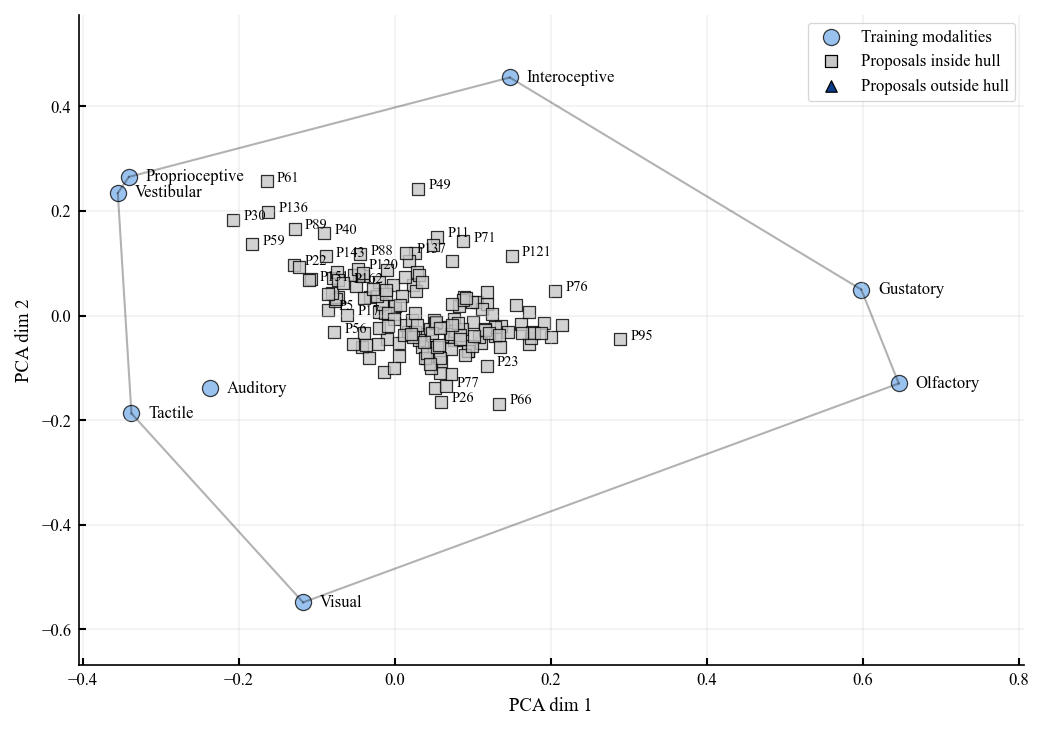

In [13]:
# Use first two PCA components from the 3D reduced space
training_2d = training_emb_reduced[:, :2]
proposal_2d = proposal_emb_reduced[:, :2]

def _modality_label(text: str) -> str:
    return str(text).replace("_", " ").strip().capitalize()

fig, ax = plt.subplots(figsize=(7, 5))

# Training modalities
train_scatter = ax.scatter(
    training_2d[:, 0], training_2d[:, 1],
    s=60,
    c=BLUE_GRAY_RAMP[2],
    marker="o",
    label="Training modalities",
    alpha=0.75,
    edgecolors="black",
)

for i, mod in enumerate(modalities):
    label = _modality_label(mod)
    ax.annotate(
        label,
        (training_2d[i, 0], training_2d[i, 1]),
        xytext=(8, 0),
        textcoords="offset points",
        ha="left",
        va="center",
        fontsize=8,
        clip_on=False,
    )

# Optional: 2D hull just for visual boundary (hull is *really* in 3D)
hull_2d_verts = None
if training_2d.shape[0] >= 3:
    hull_2d = ConvexHull(training_2d)
    hull_2d_verts = training_2d[hull_2d.vertices]
    for simplex in hull_2d.simplices:
        ax.plot(
            training_2d[simplex, 0],
            training_2d[simplex, 1],
            "k-",
            alpha=0.3,
        )

inside_color = BLUE_GRAY_RAMP[4]
outside_color = BLUE_GRAY_RAMP[0]

# Helpers for annotation overlap culling
def _pt_to_seg_dist(p, a, b):
    ab = b - a
    ap = p - a
    t = np.clip(np.dot(ap, ab) / (np.dot(ab, ab) + 1e-12), 0.0, 1.0)
    return np.linalg.norm(ap - t * ab)

def _dist_to_hull_boundary(pt, verts):
    if verts is None or len(verts) < 2:
        return float("inf")
    n = len(verts)
    return min(_pt_to_seg_dist(pt, verts[k], verts[(k + 1) % n]) for k in range(n))

inside_annot_indices = []
inside_annots = []

for i, (key, proposal) in enumerate(ai_proposals.items()):
    inside = hull_results[key]["inside_hull"]  # computed in 3D PCA space
    marker = "s" if inside else "^"
    color = inside_color if inside else outside_color

    ax.scatter(
        proposal_2d[i, 0],
        proposal_2d[i, 1],
        s=30,
        c=color,
        marker=marker,
        alpha=0.8,
        edgecolors="black",
    )

    if inside:
        ann = ax.annotate(
            f"P{i+1}",
            (proposal_2d[i, 0], proposal_2d[i, 1]),
            xytext=(5, 0),
            textcoords="offset points",
            fontsize=7,
            clip_on=True,
        )
        inside_annot_indices.append(i)
        inside_annots.append(ann)

# Cull labels in two stages:
# 1) keep only nearest-to-boundary candidates; 2) remove overlaps among those candidates.
MAX_CANDIDATE_INSIDE_LABELS = 45
hidden_count = 0
kept_count = len(inside_annots)
if inside_annots and hull_2d_verts is not None:
    hull_dists = [_dist_to_hull_boundary(proposal_2d[i], hull_2d_verts) for i in inside_annot_indices]
    fig.canvas.draw()
    renderer = fig.canvas.get_renderer()
    bboxes = [a.get_window_extent(renderer) for a in inside_annots]

    # Highest priority = smallest distance to hull boundary
    order = sorted(range(len(inside_annots)), key=lambda k: hull_dists[k])
    candidate_order = order[: min(MAX_CANDIDATE_INSIDE_LABELS, len(order))]

    keep_mask = [False] * len(inside_annots)
    kept_bboxes = []
    for k in candidate_order:
        if any(bboxes[k].overlaps(kb) for kb in kept_bboxes):
            continue
        keep_mask[k] = True
        kept_bboxes.append(bboxes[k])

    for k, ann in enumerate(inside_annots):
        if not keep_mask[k]:
            ann.set_visible(False)
            hidden_count += 1

    kept_count = len(inside_annots) - hidden_count

inside_handle = ax.scatter([], [], s=30, c=inside_color, marker="s", edgecolors="black", label="Proposals inside hull")
outside_handle = ax.scatter([], [], s=30, c=outside_color, marker="^", edgecolors="black", label="Proposals outside hull")

handles = [train_scatter, inside_handle, outside_handle]
ax.legend(handles=handles, loc="upper right")

ax.set_xlabel("PCA dim 1")
ax.set_ylabel("PCA dim 2")
# ax.set_title("Embedding Space (PCA): Training Modalities vs AI Proposals", pad=12)
ax.tick_params(axis="both")
ax.grid(True, alpha=0.3)
ax.margins(x=0.05, y=0.12)

left_xlim, right_xlim = ax.get_xlim()
ax.set_xlim(left=left_xlim, right=right_xlim + 0.10 * (right_xlim - left_xlim))

plt.tight_layout()
# Reduce spine width for a refined look
plt.subplots_adjust(left=0.08, right=0.98)
plt.savefig(output_dir / "embedding_space_analysis.png", bbox_inches="tight")
print(f"Labels kept/total (inside-hull): {kept_count} / {len(inside_annots)}")
print(f"Hidden labels: {hidden_count}")
print(f"\nVisualization saved to: {output_dir / 'embedding_space_analysis.png'}")
plt.show()



## 5. Cosine Similarity to Training Modalities

In [14]:
# Compute cosine similarities
similarity_matrix = np.zeros((len(ai_proposals), len(modalities)))

for i in range(len(proposal_embeddings)):
    for j in range(len(training_embeddings)):
        similarity_matrix[i, j] = 1 - cosine(proposal_embeddings[i], training_embeddings[j])

# Create dataframe
similarity_df = pd.DataFrame(
    similarity_matrix,
    index=[p['proposal_name'] for p in ai_proposals.values()],
    columns=[m.upper() for m in modalities]
)

print("\nCOSINE SIMILARITY TO TRAINING MODALITIES")
print("="*60)
display(similarity_df.round(3))

# Find closest training modality for each proposal
print("\nClosest Training Modality per Proposal:")
for i, (key, proposal) in enumerate(ai_proposals.items()):
    closest_idx = similarity_matrix[i].argmax()
    closest_mod = modalities[closest_idx]
    closest_sim = similarity_matrix[i, closest_idx]
    print(f"  {proposal['proposal_name']}: {closest_mod.upper()} (similarity={closest_sim:.3f})")


COSINE SIMILARITY TO TRAINING MODALITIES


,VISUAL,AUDITORY,TACTILE,OLFACTORY,GUSTATORY,PROPRIOCEPTIVE,VESTIBULAR,INTEROCEPTIVE
Chronesthesia,0.364,0.292,0.312,0.247,0.285,0.449,0.399,0.318
Temporal Resonance Perception (TRP),0.298,0.277,0.284,0.208,0.198,0.146,0.203,0.282
Chronoperception,0.298,0.295,0.319,0.258,0.254,0.349,0.324,0.347
Chronoceptive Modality,0.305,0.284,0.319,0.262,0.245,0.329,0.270,0.395
Temporoceptive,0.280,0.277,0.294,0.146,0.170,0.304,0.307,0.250
...,...,...,...,...,...,...,...,...
Chronesthetic Sense,0.352,0.333,0.334,0.275,0.273,0.340,0.344,0.309
Spacetime Strain Sense (Metricception),0.199,0.221,0.196,0.059,0.127,0.236,0.270,0.180
Chronoception,0.203,0.143,0.189,0.139,0.157,0.124,0.137,0.161
Chronoception,0.284,0.237,0.250,0.219,0.122,0.270,0.247,0.360



Closest Training Modality per Proposal:
  Chronesthesia: PROPRIOCEPTIVE (similarity=0.449)
  Temporal Resonance Perception (TRP): VISUAL (similarity=0.298)
  Chronoperception: PROPRIOCEPTIVE (similarity=0.349)
  Chronoceptive Modality: INTEROCEPTIVE (similarity=0.395)
  Temporoceptive: VESTIBULAR (similarity=0.307)
  Chronoperception: VISUAL (similarity=0.304)
  Chronoperception: VISUAL (similarity=0.349)
  Chronoception: INTEROCEPTIVE (similarity=0.276)
  Temporal Resonance Perception (TRP): VISUAL (similarity=0.225)
  Entropiception: OLFACTORY (similarity=0.166)
  Chronoceptive Modality: INTEROCEPTIVE (similarity=0.484)
  Chronoception: VISUAL (similarity=0.309)
  Quantum Coherence Sensing: VISUAL (similarity=0.226)
  Quantum Coherence Sensing: OLFACTORY (similarity=0.220)
  Chronoception: INTEROCEPTIVE (similarity=0.324)
  Entropoception: OLFACTORY (similarity=0.159)
  Chronosense: VESTIBULAR (similarity=0.355)
  Chronoception: INTEROCEPTIVE (similarity=0.275)
  Quantum Coherence M


Two-row heatmap saved to: results/similarity_heatmap_v1.png


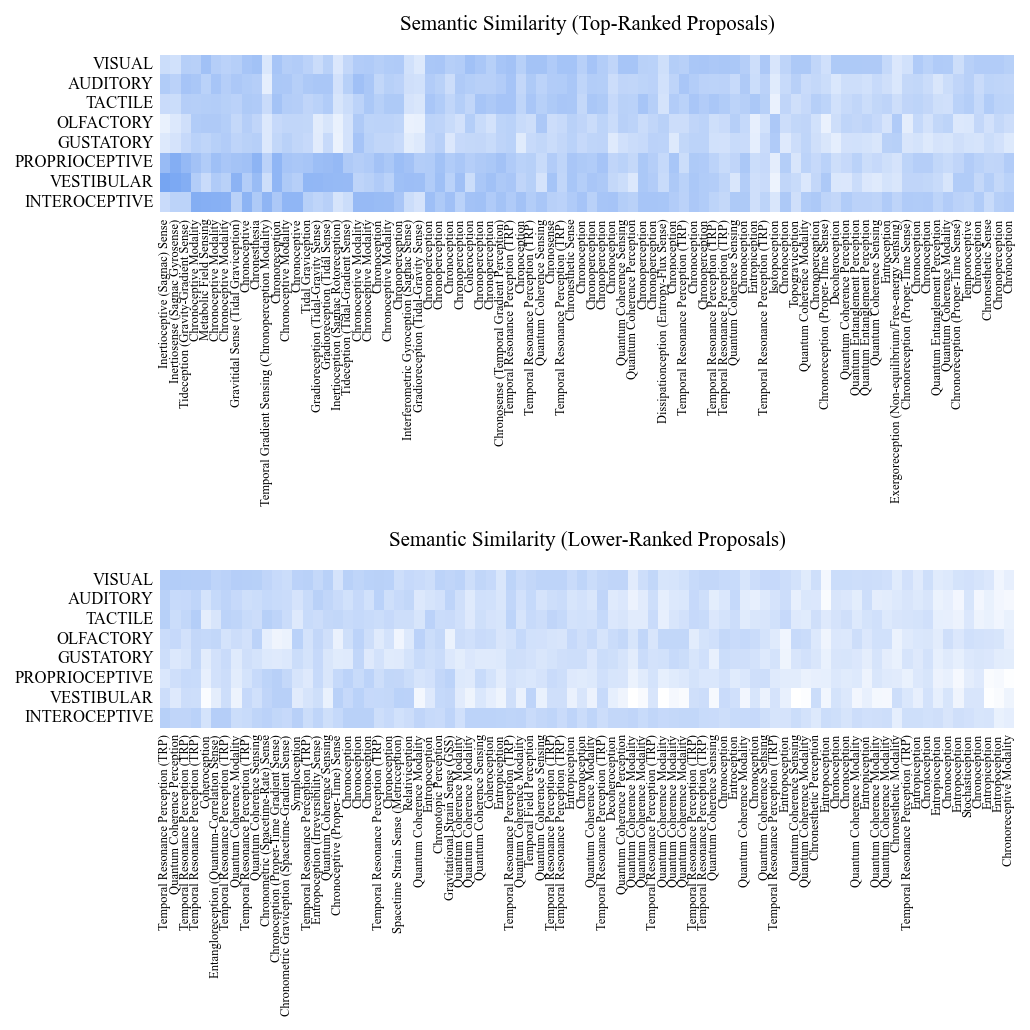

In [15]:
# Similarity heatmap: modalities on Y, proposals on X, ordered by similarity (most→least)

# Build per-proposal metadata in the same order as similarity_df rows
proposal_meta = []
for i, (key, proposal) in enumerate(ai_proposals.items()):
    proposal_name = str(proposal.get('proposal_name', f'Proposal {i+1}')).strip()
    proposal_meta.append({
        'row_idx': i,
        'proposal_id': key,
        'proposal_name': proposal_name if proposal_name else f'Proposal {i+1}',
        'max_similarity': float(similarity_df.iloc[i].max()),
    })
proposal_meta_df = pd.DataFrame(proposal_meta)

# Sort by similarity descending; tie-break by proposal name, then stable proposal id
proposal_meta_df = proposal_meta_df.sort_values(
    by=['max_similarity', 'proposal_name', 'proposal_id'],
    ascending=[False, True, True],
    kind='mergesort',
).reset_index(drop=True)

sorted_row_idx = proposal_meta_df['row_idx'].tolist()
sorted_names = proposal_meta_df['proposal_name'].tolist()

# Reorder proposals and transpose so rows are modalities and columns are proposals
sorted_similarity = similarity_df.iloc[sorted_row_idx].copy()
heatmap_df = sorted_similarity.T.copy()
heatmap_df.columns = sorted_names

# Split into top and bottom halves for readability
n_cols = heatmap_df.shape[1]
mid = (n_cols + 1) // 2
heatmap_top = heatmap_df.iloc[:, :mid]
heatmap_bottom = heatmap_df.iloc[:, mid:]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 7), gridspec_kw={'height_ratios': [1, 1]})

# Top heatmap
hm1 = sns.heatmap(
    heatmap_top,
    annot=False,
    cmap=WHITE_SKY_CMAP,
    vmin=SIMILARITY_HEATMAP_VMIN,
    vmax=SIMILARITY_HEATMAP_VMAX,
    cbar=False,
    linewidths=0.0,
    ax=ax1,
    xticklabels=True,
    yticklabels=True,
)

ax1.set_title('Semantic Similarity (Top-Ranked Proposals)')
ax1.tick_params(axis='x', rotation=90, pad=3, labelsize=6, length=0)
ax1.tick_params(axis='y', rotation=0, pad=3, length=0)

# Bottom heatmap
hm2 = sns.heatmap(
    heatmap_bottom,
    annot=False,
    cmap=WHITE_SKY_CMAP,
    vmin=SIMILARITY_HEATMAP_VMIN,
    vmax=SIMILARITY_HEATMAP_VMAX,
    cbar=False,
    #cbar_kws={'label': 'Cosine Similarity', 'pad': 0.01},
    linewidths=0.0,
    ax=ax2,
    xticklabels=True,
    yticklabels=True,
)

ax2.set_title('Semantic Similarity (Lower-Ranked Proposals)',)
ax2.tick_params(axis='x', rotation=90, pad=3, labelsize=6, length=0)
ax2.tick_params(axis='y', rotation=0, pad=3, length=0)

plt.tight_layout()
fname = output_dir / 'similarity_heatmap_v1.png'
plt.savefig(fname, bbox_inches='tight')
print(f"\nTwo-row heatmap saved to: {fname}")
plt.show()



Option A heatmap saved to: results/similarity_heatmap_v1_optionA_aggregated.png
Unique proposal names: 54 (from 168 total proposals)


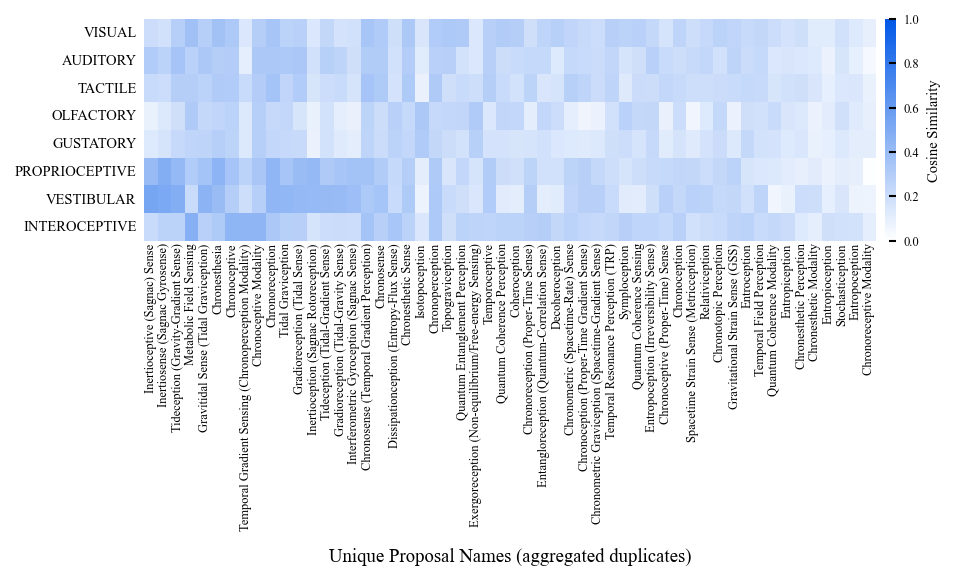

In [26]:
# Option A: aggregate duplicate proposal names (mean similarity per unique name)
# This reduces x-axis duplicates and shows one column per unique proposal name.

# Build metadata aligned to similarity_df rows
proposal_names = [str(p.get('proposal_name', '')).strip() for p in ai_proposals.values()]
proposal_names = [n if n else f'Unnamed Proposal {i+1}' for i, n in enumerate(proposal_names)]

agg_df = similarity_df.copy()
agg_df['proposal_name'] = proposal_names

# Average all rows that share the same proposal_name
agg_mean_df = agg_df.groupby('proposal_name', sort=False).mean(numeric_only=True)

# Sort unique names by their strongest modality similarity (descending), tie by name
agg_order_df = (
    agg_mean_df.assign(max_similarity=agg_mean_df.max(axis=1))
    .sort_values(by=['max_similarity', 'proposal_name'], ascending=[False, True], kind='mergesort')
)
agg_sorted = agg_order_df.drop(columns=['max_similarity'])

# Transpose: modalities on Y, unique proposal names on X
heatmap_agg = agg_sorted.T

fig, ax = plt.subplots(figsize=(7, 4))  # taller for longer names
hm = sns.heatmap(
    heatmap_agg,
    annot=False,
    cmap=WHITE_SKY_CMAP,
    center=0.5,
    vmin=SIMILARITY_HEATMAP_VMIN,
    vmax=SIMILARITY_HEATMAP_VMAX,
    cbar_kws={'label': 'Cosine Similarity', 'pad': 0.01},
    linewidths=0.0,
    ax=ax,
    xticklabels=True,
    yticklabels=True,
)

# ax.set_title('Mean Similarity by Unique Proposal Name')
ax.set_xlabel('Unique Proposal Names (aggregated duplicates)', labelpad=8)
# ax.set_ylabel('Training Modalities', labelpad=8)
ax.tick_params(axis='x', rotation=90, pad=1, length=0, labelsize=6)
ax.tick_params(axis='y', rotation=0, length=0, labelsize=7)

cbar = hm.collections[0].colorbar
cbar.ax.tick_params(labelsize=6)
cbar.set_label('Cosine Similarity', fontsize=7)

plt.tight_layout()
fname = output_dir / 'similarity_heatmap_v1_optionA_aggregated.png'
plt.savefig(fname, bbox_inches='tight')
print(f"\nOption A heatmap saved to: {fname}")
print(f"Unique proposal names: {heatmap_agg.shape[1]} (from {len(ai_proposals)} total proposals)")
plt.show()


In [17]:
# Alternative visualization focusing on extremes and using white->skyblue colormap
# Keep exactly N highest + N lowest instances, with a visual gap row between groups.
# ipywidgets toggle to switch Portrait/Landscape (default: Portrait).

# Build row-level metadata with unique row IDs (prevents duplicate-name over-selection)
proposal_names = [str(p.get('proposal_name', '')).strip() for p in ai_proposals.values()]
proposal_names = [n if n else f'Unnamed Proposal {i+1}' for i, n in enumerate(proposal_names)]
max_sim = similarity_df.max(axis=1).values

meta = pd.DataFrame(
    {
        'row_id': np.arange(len(similarity_df)),
        'proposal_name': proposal_names,
        'maxsim': max_sim,
    }
)

# Deterministic ordering by similarity and name
desc = meta.sort_values(['maxsim', 'proposal_name', 'row_id'], ascending=[False, True, True], kind='mergesort')
asc = meta.sort_values(['maxsim', 'proposal_name', 'row_id'], ascending=[True, True, True], kind='mergesort')

# Select N highest and N lowest unique row IDs
top_ids = desc.head(EXTREMES_GROUP_SIZE)['row_id'].tolist()
bottom_ids = [rid for rid in asc.head(EXTREMES_GROUP_SIZE)['row_id'].tolist() if rid not in top_ids]

# Guarantee exactly N + N rows when possible
if len(bottom_ids) < EXTREMES_GROUP_SIZE:
    remaining_for_bottom = [rid for rid in asc['row_id'].tolist() if rid not in top_ids and rid not in bottom_ids]
    bottom_ids.extend(remaining_for_bottom[: EXTREMES_GROUP_SIZE - len(bottom_ids)])

top_meta = meta.set_index('row_id').loc[top_ids].reset_index().sort_values(
    ['maxsim', 'proposal_name', 'row_id'], ascending=[False, True, True], kind='mergesort'
)
bottom_meta = meta.set_index('row_id').loc[bottom_ids].reset_index().sort_values(
    ['maxsim', 'proposal_name', 'row_id'], ascending=[False, True, True], kind='mergesort'
)

selected_meta = pd.concat([top_meta, bottom_meta], ignore_index=True)
sub_df = similarity_df.iloc[selected_meta['row_id'].tolist()].copy()

# Build y-axis labels as real proposal names; disambiguate only duplicate names
name_totals = selected_meta['proposal_name'].value_counts().to_dict()
name_seen = {}
y_labels = []
for name in selected_meta['proposal_name']:
    name_seen[name] = name_seen.get(name, 0) + 1
    if name_totals[name] > 1:
        y_labels.append(f"{name} ({name_seen[name]})")
    else:
        y_labels.append(name)
sub_df.index = y_labels

# Insert one blank separator row between top and bottom groups
separator = pd.DataFrame([[np.nan] * sub_df.shape[1]], columns=sub_df.columns, index=[''])
plot_df = pd.concat([sub_df.iloc[:EXTREMES_GROUP_SIZE], separator, sub_df.iloc[EXTREMES_GROUP_SIZE:]], axis=0)

# Custom annotation strings to keep separator row empty
annot_text = plot_df.applymap(lambda v: '' if pd.isna(v) else f"{v:.3f}")


def render_extremes_heatmap(orientation='portrait'):
    orientation = str(orientation).lower().strip()

    if orientation == 'landscape':
        fig_size = (7, 6)
    else:
        fig_size = (6, 7)
        orientation = 'portrait'

    fig, ax = plt.subplots(figsize=fig_size)

    sns.heatmap(
        plot_df,
        annot=annot_text,
        fmt='',
        cmap=WHITE_SKY_CMAP,
        center=0.5,
        vmin=SIMILARITY_HEATMAP_VMIN,
        vmax=SIMILARITY_HEATMAP_VMAX,
        annot_kws={'fontsize': 7, 'color': 'black'},
        cbar_kws={'label': 'Cosine Similarity', 'shrink': 1.0, 'pad': 0.01, 'aspect':70},
        linewidths=0.35,
        ax=ax,
    )

    # Dashed line through the separator row center
    sep = EXTREMES_GROUP_SIZE + 0.5
    ax.hlines(sep, xmin=0, xmax=plot_df.shape[1], colors='k', linestyles='--', linewidth=0.8)

    ax.set_title(f'Semantic Similarity: {EXTREMES_GROUP_SIZE} Highest + {EXTREMES_GROUP_SIZE} Lowest', fontsize=10, pad=8)
    ax.set_xlabel('Training Modalities')
    ax.set_ylabel('AI Proposals (real names)')
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=7)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=7)
    ax.tick_params(axis='both', length=0)

    cbar = ax.collections[0].colorbar
    cbar.ax.tick_params(labelsize=6)
    cbar.set_label('Cosine Similarity', fontsize=7)

    plt.tight_layout(pad=0.4)
    fname = output_dir / f'similarity_heatmap_v2_a4_{orientation}.png'
    plt.savefig(fname)

    print(f"\nHeatmap saved to: {fname}")
    print(f"A4 size (in): {fig_size[0]} x {fig_size[1]}")
    print(f"Proposal rows displayed: {sub_df.shape[0]} (expected {EXTREMES_GROUP_SIZE * 2} when total proposals is sufficient)")
    print(f"Total heatmap rows including separator: {plot_df.shape[0]}")
    print(f"Top-group first row max similarity: {top_meta.iloc[0]['maxsim']:.3f}")
    print(f"Bottom-group last row max similarity: {bottom_meta.iloc[-1]['maxsim']:.3f}")
    plt.show()


layout_toggle = widgets.ToggleButtons(
    options=[('Portrait (A4)', 'portrait'), ('Landscape (A4)', 'landscape')],
    value='portrait',
    description='Layout:',
    button_style='',
)

interactive_out = widgets.interactive_output(render_extremes_heatmap, {'orientation': layout_toggle})
display(layout_toggle, interactive_out)


ToggleButtons(description='Layout:', options=(('Portrait (A4)', 'portrait'), ('Landscape (A4)', 'landscape')),…

Output()

## 6. Literature Traceability Analysis

This section is organized in execution order:

1. Collect/refresh internet literature corpus.
2. Build/load the default traceability corpus and retrieval index from collected data.
3. Continue to summary reporting in Section 7.

### 6.1 Automated Internet Collection

Run the next three cells to refresh `data/literature_corpus/traceability_collected.csv` before building the traceability index.

#### 6.1.1 Import Collection Utilities and Similarity Tools

Imports the reusable literature collection functions and cosine similarity utility used by the traceability pipeline.

In [18]:
# Import literature collection and traceability functions
from literature_collection import collect_literature_dataset, save_collected_corpus

# Literature traceability using collected scholarly corpus (default method)
from sklearn.metrics.pairwise import cosine_similarity

# Retrieval and collection thresholds are declared globally at notebook start.
print(
    f"Traceability config: top_k={TRACEABILITY_TOP_K}, threshold={TRACEABILITY_SIM_THRESHOLD}, "
    f"min_query_chars={TRACEABILITY_MIN_QUERY_CHARS}, min_doc_chars={TRACEABILITY_MIN_DOC_CHARS}"
)

Traceability config: top_k=10, threshold=0.4, min_query_chars=60, min_doc_chars=120


#### 6.1.2 Build Collection Query Set

Constructs a compact query list from core sensory topics plus proposal names.

In [19]:
# Build search queries for automated literature collection
# You can tune this list before running the collector cell.

core_topics = [
    'sensory modality',
    'novel sensory modality',
    'multisensory integration',
    'interoception',
    'proprioception',
    'vestibular perception',
    'computational neuroscience sensory',
    'sensorimotor representation',
]

# Use proposal names/descriptions as additional query seeds
proposal_terms = []
for _, proposal in ai_proposals.items():
    name = str(proposal.get('proposal_name', '')).strip()
    if name:
        proposal_terms.append(name)

# Keep a compact unique set to avoid excessive API traffic
seed_terms = list(dict.fromkeys(core_topics + proposal_terms))
literature_queries = seed_terms[:MAX_QUERY_TERMS]

print(f'Prepared {len(literature_queries)} literature queries (cap={MAX_QUERY_TERMS}).')
print(literature_queries[:12])

Prepared 30 literature queries (cap=30).
['sensory modality', 'novel sensory modality', 'multisensory integration', 'interoception', 'proprioception', 'vestibular perception', 'computational neuroscience sensory', 'sensorimotor representation', 'Chronesthesia', 'Temporal Resonance Perception (TRP)', 'Chronoperception', 'Chronoceptive Modality']


#### 6.1.3 Collect and Save Scholarly Corpus (On Demand)

Use the button below to run API collection only when needed, then save the cleaned corpus to `data/literature_corpus/traceability_collected.csv`.

In [20]:
# Collect literature from OpenAlex and Crossref only when button is pressed
out_file = Path('data/literature_corpus/traceability_collected.csv')

target_docs_widget = widgets.IntText(
    value=int(TARGET_DOCS),
    description='Target docs:',
    layout=widgets.Layout(width='240px')
)

email_widget = widgets.Text(
    value=str(CONTACT_EMAIL),
    description='Contact email:',
    placeholder='you@university.edu',
    layout=widgets.Layout(width='420px')
)

run_collection_button = widgets.Button(
    description='Collect / Refresh Corpus',
    button_style='primary',
    icon='download',
    tooltip='Run literature collection and overwrite corpus CSV'
)

collection_status_out = widgets.Output()

def _run_corpus_collection(_):
    global internet_lit_df, TARGET_DOCS, CONTACT_EMAIL
    run_collection_button.disabled = True
    with collection_status_out:
        collection_status_out.clear_output(wait=True)
        TARGET_DOCS = int(target_docs_widget.value)
        CONTACT_EMAIL = str(email_widget.value).strip()

        print('Starting literature collection...')
        print(f'TARGET_DOCS={TARGET_DOCS}, CONTACT_EMAIL={CONTACT_EMAIL or "<empty>"}')
        print(
            f'Collector thresholds: min_text_chars={COLLECT_MIN_TEXT_CHARS}, '
            f'openalex_per_query={OPENALEX_PER_QUERY}, openalex_pages={OPENALEX_PAGES}, '
            f'crossref_per_query={CROSSREF_PER_QUERY}'
        )

        internet_lit_df = collect_literature_dataset(
            queries=literature_queries,
            target_n=TARGET_DOCS,
            per_query_openalex=OPENALEX_PER_QUERY,
            pages_openalex=OPENALEX_PAGES,
            per_query_crossref=CROSSREF_PER_QUERY,
            min_text_chars=COLLECT_MIN_TEXT_CHARS,
            mailto=CONTACT_EMAIL or None,
)

        if internet_lit_df.empty:
            print('No records collected. Check internet connection and query set.')
        else:
            internet_lit_df = save_collected_corpus(internet_lit_df, out_file)
            print(f'Collected {len(internet_lit_df)} documents.')
            print(f'Saved to: {out_file}')
            print('\nAPI contribution:')
            print(internet_lit_df['api'].value_counts().to_string())
            has_tags = internet_lit_df['text'].str.contains(r'<jats:|<[^>]+>', case=False, na=False, regex=True).any()
            has_boilerplate_prefix = internet_lit_df['text'].str.contains(r'(?i)^\s*(abstract|background|summary|significance statement)\b', na=False, regex=True).any()
            print(f'Tag cleanup check in collected text (should be False): {has_tags}')
            print(f'Leading boilerplate check in collected text (should be False): {has_boilerplate_prefix}')
            display(internet_lit_df.head(10))
    run_collection_button.disabled = False

run_collection_button.on_click(_run_corpus_collection)

display(widgets.VBox([target_docs_widget, email_widget, run_collection_button, collection_status_out]))

if out_file.exists():
    print(f'Current corpus file found: {out_file}')
    print('Use the button above only when you want to refresh it.')
else:
    print(f'Corpus file not found yet: {out_file}')
    print('Press the button above to create it.')

Current corpus file found: data/literature_corpus/traceability_collected.csv
Use the button above only when you want to refresh it.


### 6.2 Build Traceability Functions

Defines text sanitization, corpus mapping, index construction, and literature search helpers.

In [21]:
def sanitize_literature_text(text):
    """Normalize literature text by removing XML/HTML tags and collapsing whitespace."""
    txt = '' if text is None else str(text)
    txt = re.sub(r'<[^>]+>', ' ', txt)  # strips JATS/XML/HTML tags like <jats:p>
    txt = txt.replace('\n', ' ').replace('\r', ' ')
    txt = ' '.join(txt.split()).strip()
    txt = re.sub(r'(?i)^\s*(abstract|background|summary|significance statement)\s*[:\-]?\s*', '', txt).strip()
    return txt

def _build_default_traceability_corpus():
    collected_path = Path('data/literature_corpus/traceability_collected.csv')

    if collected_path.exists():
        collected_df = pd.read_csv(collected_path)
        mapped = pd.DataFrame({
            'doc_id': collected_df.get('doc_id', pd.Series(dtype=str)).astype(str),
            'title': collected_df.get('title', pd.Series(dtype=str)).astype(str),
            'text': collected_df.get('text', pd.Series(dtype=str)).astype(str),
            'source_type': 'internet_scholarly_api',
            'source_path': collected_df.get('url', pd.Series(dtype=str)).astype(str),
            'evidence_tier': 'strong',
        })
        mapped = mapped.dropna(subset=['text']).copy()
        mapped['title'] = mapped['title'].map(sanitize_literature_text)
        mapped['text'] = mapped['text'].map(sanitize_literature_text)
        mapped = mapped[mapped['text'].str.len() >= TRACEABILITY_MIN_DOC_CHARS].copy()
        mapped = mapped.drop_duplicates(subset=['doc_id'], keep='first').reset_index(drop=True)

        if not mapped.empty:
            print(f'Using collected literature corpus: {len(mapped)} rows from {collected_path}')
            return mapped

    # Fallback only when collected corpus is unavailable
    seed_rows = []
    for mod, desc in modality_descriptions.items():
        seed_rows.append({
            'doc_id': f'ontology_{mod}',
            'title': f'Ontology seed: {mod}',
            'text': sanitize_literature_text(desc),
            'source_type': 'ontology_seed',
            'source_path': 'data/ontology.json',
            'evidence_tier': 'weak',
        })
    print('Warning: collected corpus not found; using ontology seed fallback.')
    return pd.DataFrame(seed_rows)


def build_traceability_index(corpus_df):
    if corpus_df.empty:
        raise ValueError('traceability corpus is empty.')

    text_list = corpus_df['text'].astype(str).tolist()
    embeddings = embedder.encode(text_list)

    return {
        'corpus_df': corpus_df.reset_index(drop=True).copy(),
        'embeddings': embeddings,
    }


def search_training_literature(proposal_text, top_k=TRACEABILITY_TOP_K, threshold=TRACEABILITY_SIM_THRESHOLD, min_chars=TRACEABILITY_MIN_QUERY_CHARS, traceability_index=None):
    """
    Search traceability corpus and return provenance-aware matches.
    """
    if traceability_index is None:
        traceability_index = default_traceability_index # type: ignore

    corpus_df = traceability_index['corpus_df']
    corpus_embeddings = traceability_index['embeddings']

    q = sanitize_literature_text(proposal_text)
    if len(q) < min_chars:
        return []

    query_emb = embedder.encode([q])
    sims = cosine_similarity(query_emb, corpus_embeddings)[0]
    idx_sorted = np.argsort(sims)[::-1]

    results = []
    for idx in idx_sorted[:top_k]:
        score = float(sims[idx])
        if threshold is not None and score < threshold:
            continue

        row = corpus_df.iloc[int(idx)]
        results.append({
            'index': int(idx),
            'text': row['text'],
            'score': score,
            'title': row['title'],
            'source_type': row['source_type'],
            'evidence_tier': row['evidence_tier'],
            'source_path': row['source_path'],
        })

    return results

### 6.3 Initialize Traceability Index and Run Sanity Checks

Applies retrieval settings, builds the default index from collected corpus, and prints quality checks plus sample matches.

In [22]:
# Initialize default corpus/index for the main pipeline
traceability_corpus_df = _build_default_traceability_corpus()
default_traceability_index = build_traceability_index(traceability_corpus_df)

print(f'Traceability retrieval settings: top_k={TRACEABILITY_TOP_K}, threshold={TRACEABILITY_SIM_THRESHOLD}')
print('Traceability corpus source type distribution:')
print(traceability_corpus_df['source_type'].value_counts().to_string())
print('Traceability evidence tier distribution:')
print(traceability_corpus_df['evidence_tier'].value_counts().to_string())

# Quick check: ensure JATS/XML tags were removed before embedding
has_jats = traceability_corpus_df['text'].str.contains(r'<jats:|<[^>]+>', case=False, na=False, regex=True).any()
has_boilerplate_prefix = traceability_corpus_df['text'].str.contains(r'(?i)^\s*(abstract|background|summary|significance statement)\b', na=False, regex=True).any()
print(f'Tag cleanup check (should be False): {has_jats}')
print(f'Leading boilerplate check (should be False): {has_boilerplate_prefix}')

# Example usage
for key, proposal in list(ai_proposals.items())[:5]:
    matches = search_training_literature(proposal['description'])
    print(f"\n{key}: Found {len(matches)} similar corpus documents")
    for m in matches[:3]:
        print(f"   {m['score']:.3f} | {m['source_type']} | {m['title'][:70]}")

Using collected literature corpus: 125 rows from data/literature_corpus/traceability_collected.csv
Traceability retrieval settings: top_k=10, threshold=0.4
Traceability corpus source type distribution:
source_type
internet_scholarly_api    125
Traceability evidence tier distribution:
evidence_tier
strong    125
Tag cleanup check (should be False): False
Leading boilerplate check (should be False): False

sample_000: Found 10 similar corpus documents
   0.564 | internet_scholarly_api | Temporal Experience and Human State Field: Toward a New Framework Brid
   0.559 | internet_scholarly_api | Direction- and Velocity-Specific Responses from beyond the Classical R
   0.542 | internet_scholarly_api | Temporal Instabilities in Amblyopic Perception: A Quantitative Approac

sample_001: Found 4 similar corpus documents
   0.451 | internet_scholarly_api | Temporal Experience and Human State Field: Toward a New Framework Brid
   0.431 | internet_scholarly_api | Perception of Temporal Patterns
   0

## 7. Summary Results

In [23]:
# Compile comprehensive results
final_results = []

for i, (key, proposal) in enumerate(ai_proposals.items()):
    decomp = decomposition_results[key]
    hull_res = hull_results[key]
    closest_idx = similarity_matrix[i].argmax()

    # Literature traceability search on default corpus
    lit_matches = search_training_literature(
        proposal['description'],
        top_k=TRACEABILITY_TOP_K,
        threshold=TRACEABILITY_SIM_THRESHOLD,
    )
    if lit_matches:
        best = lit_matches[0]
        lit_score = best['score']
        lit_text = best['text']
        lit_title = best.get('title', '')
        lit_source_type = best.get('source_type', '')
        lit_evidence_tier = best.get('evidence_tier', '')
        lit_count = len(lit_matches)
    else:
        lit_score = None
        lit_text = ''
        lit_title = ''
        lit_source_type = ''
        lit_evidence_tier = ''
        lit_count = 0

    # Minimal continuous novelty score for downstream overview usage.
    # semantic component in [0,1]: farther from nearest training modality => higher novelty
    max_similarity_val = float(similarity_matrix[i, closest_idx])
    novelty_semantic_proxy = float(np.clip(1.0 - max_similarity_val, 0.0, 1.0))

    # frontier proxy: count violated structural/traceability gates
    novelty_frontier_distance_proxy = float(
        int(bool(decomp['is_extension']))
        + int(bool(decomp['is_hybrid']))
        + int(bool(decomp['is_functional_recombination']))
        + int(bool(hull_res['inside_hull']))
        + int(lit_count > 0)
    )

    # final continuous score in [0,1]: semantic novelty discounted by frontier violations
    continuous_novelty_score = float(
        np.clip(novelty_semantic_proxy * np.exp(-novelty_frontier_distance_proxy), 0.0, 1.0)
    )

    result = {
        'proposal_id': key,
        'proposal_name': proposal['proposal_name'],
        'model': proposal['model'],
        'is_extension': decomp['is_extension'],
        'is_hybrid': decomp['is_hybrid'],
        'is_functional_recomb': decomp['is_functional_recombination'],
        'is_traceable': lit_count > 0,
        'related_modalities': ', '.join(decomp['related_modalities']),
        'inside_convex_hull': hull_res['inside_hull'],
        'closest_modality': modalities[closest_idx].upper(),
        'max_similarity': max_similarity_val,
        'avg_similarity': similarity_matrix[i].mean(),
        'lit_matches': lit_count,
        'lit_best_score': lit_score,
        'lit_best_text': lit_text,
        'lit_best_title': lit_title,
        'lit_best_source_type': lit_source_type,
        'lit_best_evidence_tier': lit_evidence_tier,
        'novelty_semantic_proxy': novelty_semantic_proxy,
        'novelty_frontier_distance_proxy': novelty_frontier_distance_proxy,
        'continuous_novelty_score': continuous_novelty_score,
        'is_novel': 'NO' if (decomp['is_extension'] or decomp['is_hybrid'] or
                                        decomp['is_functional_recombination'] or
                                        hull_res['inside_hull']) else 'MAYBE'
    }
    final_results.append(result)

results_df = pd.DataFrame(final_results)

print("\n" + "="*80)
print("FINAL RESULTS: TEST 1 - ONTOLOGICAL INNOVATION")
print("="*80)
print(results_df.to_string(index=False))

# Save results
results_df.to_csv(output_dir / 'test1_results.csv', index=False)
print(f"\nResults saved to: {output_dir / 'test1_results.csv'}")

# Summary statistics
print("\n" + "="*80)
print("SUMMARY STATISTICS")
print("="*80)
print(f"Total proposals analyzed: {len(ai_proposals)}")
print(f"Structurally decomposable: {results_df[['is_extension', 'is_hybrid', 'is_functional_recomb']].any(axis=1).sum()}")
print(f"Inside convex hull: {results_df['inside_convex_hull'].sum()}")
print(f"Mean similarity to training: {results_df['avg_similarity'].mean():.3f}")
print(f"Possibly ontologically novel: {(results_df['is_novel'] == 'MAYBE').sum()}")
print(f"Clearly traceable to training: {(results_df['is_novel'] == 'NO').sum()}")
print(f"Median continuous novelty score: {results_df['continuous_novelty_score'].median():.3f}")

if 'lit_best_score' in results_df.columns:
    print(f"Average literature match score: {results_df['lit_best_score'].dropna().mean():.3f}")
    print(f"Proposals with >=1 literature match: {(results_df['lit_matches'] > 0).sum()}")
    print('lit_matches distribution (threshold-filtered):')
    print(results_df['lit_matches'].value_counts(dropna=False).sort_index().to_string())
    if 'lit_best_evidence_tier' in results_df.columns:
        print('Best-match evidence tier distribution:')
        print(results_df['lit_best_evidence_tier'].value_counts(dropna=False).to_string())
    if 'lit_best_source_type' in results_df.columns:
        print('Best-match source type distribution:')
        print(results_df['lit_best_source_type'].value_counts(dropna=False).to_string())


FINAL RESULTS: TEST 1 - ONTOLOGICAL INNOVATION
proposal_id                                         proposal_name                  model  is_extension  is_hybrid  is_functional_recomb  is_traceable                                          related_modalities  inside_convex_hull closest_modality  max_similarity  avg_similarity  lit_matches  lit_best_score                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                     

## 8. Generate Report for Paper

This section generates formatted text you can insert into Section 5.2 of your paper.

In [24]:
# Generate prose summary for paper
lit_mean = results_df['lit_best_score'].dropna().mean() if 'lit_best_score' in results_df.columns else float('nan')
strong_best = 0
if 'lit_best_evidence_tier' in results_df.columns:
    strong_best = int((results_df['lit_best_evidence_tier'] == 'strong').sum())

report = f"""
Test 1 Results: Ontological Innovation in Sensory Modalities

We analyzed {len(ai_proposals)} proposals for novel sensory modalities generated by AI systems 
across multiple models. Evaluation employed four convergent methods: structural decomposition, 
embedding space analysis, semantic similarity measurement, and literature traceability.

Structural Decomposition: {decomposable}/{len(ai_proposals)} proposals ({decomposable/len(ai_proposals)*100:.1f}%) 
were structurally decomposable into existing training modalities. Common patterns included:

- Range Extension ({sum(1 for r in decomposition_results.values() if r['is_extension'])} cases): 
  Proposals extending electromagnetic or acoustic ranges while preserving existing sensory primitives.

- Hybrid Combinations ({sum(1 for r in decomposition_results.values() if r['is_hybrid'])} cases): 
  Proposals combining features from multiple existing modalities.

- Functional Recombination ({sum(1 for r in decomposition_results.values() if r['is_functional_recombination'])} cases): 
  Proposals repurposing existing sensory mechanisms for different functional roles.

Embedding Space Analysis: Convex hull testing revealed {inside_count}/{len(ai_proposals)} proposals 
({inside_count/len(ai_proposals)*100:.1f}%) lie within the convex hull of training modality embeddings, 
indicating representability through combinations of existing concepts.

Semantic Similarity: Mean cosine similarity between proposals and closest training modality was 
{results_df['max_similarity'].mean():.3f} (SD={results_df['max_similarity'].std():.3f}), indicating 
substantial semantic overlap with training concepts.

Literature Traceability (Internet Corpus): The default traceability pipeline used the collected scholarly corpus 
(`data/literature_corpus/traceability_collected.csv`) with provenance metadata. Average best-match score was 
{lit_mean:.3f}; {strong_best}/{len(ai_proposals)} proposals had a best match from strong evidence tier sources.

Conclusion: Across all evaluation methods, {(results_df['is_novel'] == 'NO').sum()}/{len(ai_proposals)} 
proposals remained traceable to known concepts through recombination, extension, or close semantic alignment.
"""

print(report)

# Save report
with open(output_dir / 'test1_paper_section.txt', 'w') as f:
    f.write(report)

print(f"\nReport saved to: {output_dir / 'test1_paper_section.txt'}")
print("\nAnalysis complete! Review results and insert into Section 5.2 of your paper.")


Test 1 Results: Ontological Innovation in Sensory Modalities

We analyzed 168 proposals for novel sensory modalities generated by AI systems 
across multiple models. Evaluation employed four convergent methods: structural decomposition, 
embedding space analysis, semantic similarity measurement, and literature traceability.

Structural Decomposition: 88/168 proposals (52.4%) 
were structurally decomposable into existing training modalities. Common patterns included:

- Range Extension (34 cases): 
  Proposals extending electromagnetic or acoustic ranges while preserving existing sensory primitives.

- Hybrid Combinations (75 cases): 
  Proposals combining features from multiple existing modalities.

- Functional Recombination (30 cases): 
  Proposals repurposing existing sensory mechanisms for different functional roles.

Embedding Space Analysis: Convex hull testing revealed 168/168 proposals 
(100.0%) lie within the convex hull of training modality embeddings, 
indicating representa

In [25]:
# Threshold calibration helper for T1_TRACEABILITY_SIM_THRESHOLD
# Compares candidate thresholds: 0.30, 0.40, 0.50
def _sanitize_literature_text(text):
    txt = '' if text is None else str(text)
    txt = re.sub(r'<[^>]+>', ' ', txt)
    txt = txt.replace('\n', ' ').replace('\r', ' ')
    txt = ' '.join(txt.split()).strip()
    txt = re.sub(r'(?i)^\s*(abstract|background|summary|significance statement)\s*[:\-]?\s*', '', txt).strip()
    return txt


def _extract_json(text):
    match = re.search(r"\{.*\}", text, re.DOTALL)
    if not match:
        return None
    try:
        return json.loads(match.group(0))
    except json.JSONDecodeError:
        return None


def _word_count(text):
    if not isinstance(text, str):
        return 0
    return len(re.findall(r"\b\w+\b", text))

responses_path = Path("ai_responses/all_responses.json")
corpus_path = Path("data/literature_corpus/traceability_collected.csv")

with responses_path.open("r", encoding="utf-8") as f:
    raw_responses_local = json.load(f)

proposal_texts = []
for item in raw_responses_local:
    if item.get("finish_reason") not in ["stop", None]:
        continue
    response_text = item.get("response", "")
    if _word_count(response_text) <= MIN_RESPONSE_WORDS:
        continue

    parsed = _extract_json(response_text)
    if parsed is not None:
        physical_basis = (parsed.get("physical_basis") or "").strip()
        information_content = (parsed.get("information_content") or "").strip()
        functional_role = (parsed.get("functional_role") or "").strip()
        description = (parsed.get("description") or "").strip()
        if not description:
            description = " ".join(
                part for part in [physical_basis, information_content, functional_role] if part
            ).strip()
        text = description
    else:
        text = response_text.strip()

    if text:
        proposal_texts.append(text)

corpus_df = pd.read_csv(corpus_path)
corpus_texts = corpus_df.get("text", pd.Series(dtype=str)).astype(str).map(_sanitize_literature_text)
corpus_texts = corpus_texts[corpus_texts.str.len() >= TRACEABILITY_MIN_DOC_CHARS].tolist()

embedder_cal = SentenceTransformer(EMBED_MODEL_NAME)
proposal_emb = embedder_cal.encode(proposal_texts)
corpus_emb = embedder_cal.encode(corpus_texts)

sim_matrix = cosine_similarity(proposal_emb, corpus_emb)
max_scores = sim_matrix.max(axis=1)

candidates = [0.30, 0.40, 0.50]
rows = []
for t in candidates:
    docs_above = (sim_matrix >= t).sum(axis=1)
    rows.append({
        "threshold": t,
        "traceable_rate": float((max_scores >= t).mean()),
        "mean_docs_above_t": float(docs_above.mean()),
        "median_docs_above_t": float(np.median(docs_above)),
        "p90_docs_above_t": float(np.percentile(docs_above, 90)),
    })

calib_df = pd.DataFrame(rows)

print(f"Proposals after quality gates: {len(proposal_texts)}")
print(f"Corpus documents (length-filtered): {len(corpus_texts)}")
print("\nMax-score quantiles:")
for q in [0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95]:
    print(f"  q{int(q*100):02d}: {np.quantile(max_scores, q):.4f}")

print("\nCandidate comparison:")
display(calib_df.round(4))

rates = calib_df["traceable_rate"].tolist()
print("\nTraceable-rate drops:")
print(f"  0.30 -> 0.40: {rates[0] - rates[1]:.4f}")
print(f"  0.40 -> 0.50: {rates[1] - rates[2]:.4f}")

Proposals after quality gates: 168
Corpus documents (length-filtered): 125

Max-score quantiles:
  q05: 0.4260
  q10: 0.4394
  q25: 0.4783
  q50: 0.5250
  q75: 0.5722
  q90: 0.6065
  q95: 0.6294

Candidate comparison:


,threshold,traceable_rate,mean_docs_above_t,median_docs_above_t,p90_docs_above_t
0,0.3,1.0000,23.7202,20.0,41.0
1,0.4,0.9821,7.3571,7.0,14.0
2,0.5,0.6488,1.2381,1.0,2.3



Traceable-rate drops:
  0.30 -> 0.40: 0.0179
  0.40 -> 0.50: 0.3333
